In [3]:
import pandas as pd
df  = pd.read_csv('../../HLM_V1/hlm_simulated_data_new.csv')
df.head()

,區域,區域code,數位政策推行,數位政策推行code,武力預算展現,食物產出,論文數,學校,學校類型,學校類型code,數位使用,數位使用code,學校經費,師生比,學生,AI使用程度,AI使用程度code,英語能力,英語能力code,認知表現
0,非洲,1,無,0,951.207163,5291,3822,Country_1_School_1,都市,3,無,0,1735.172195,12.857336,Country_1_School_1_Student_1,低,1,高,3,-0.226555
1,非洲,1,無,0,951.207163,5291,3822,Country_1_School_1,都市,3,無,0,1735.172195,12.857336,Country_1_School_1_Student_2,中,2,高,3,-0.074144
2,非洲,1,無,0,951.207163,5291,3822,Country_1_School_1,都市,3,無,0,1735.172195,12.857336,Country_1_School_1_Student_3,中,2,低,1,-0.552607
3,非洲,1,無,0,951.207163,5291,3822,Country_1_School_1,都市,3,無,0,1735.172195,12.857336,Country_1_School_1_Student_4,低,1,高,3,-0.523379
4,非洲,1,無,0,951.207163,5291,3822,Country_1_School_1,都市,3,無,0,1735.172195,12.857336,Country_1_School_1_Student_5,低,1,高,3,-0.143379


In [5]:
g3 = "區域"
var = "數位政策推行code"
grouped = df.groupby(g3)[var].agg(
    樣本數='count', 最小值='min', 最大值='max', 平均數='mean', 標準差='std'
).reset_index().rename(columns={g3: '組別'})
for col in ['最小值', '最大值', '平均數', '標準差']:
    grouped[col] = grouped[col].round(2)
total_row = {
    '組別': '總和',
    '樣本數': int(df[var].count()),
    '最小值': round(float(df[var].min()), 2),
    '最大值': round(float(df[var].max()), 2),
    '平均數': round(float(df[var].mean()), 2),
    '標準差': round(float(df[var].std()), 2),
}
total_row

{'組別': '總和', '樣本數': 1500, '最小值': 0.0, '最大值': 3.0, '平均數': 1.6, '標準差': 1.08}

In [7]:
eu = df[df['區域']== "歐洲"]
eu['數位政策推行code'].value_counts()

數位政策推行code
0    100
Name: count, dtype: int64

In [6]:
grouped

,組別,樣本數,最小值,最大值,平均數,標準差
0,亞洲,700,0,3,1.57,1.05
1,歐洲,100,0,0,0.00,0.00
2,美洲,300,1,3,2.33,0.94
3,非洲,400,0,2,1.50,0.87


In [11]:
import arviz.preview as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import statsmodels.api as sm
import seaborn.objects as so

# az.style.use("arviz-variat")
SEED = 2611

In [9]:
# Load up data from statsmodels
df = sm.datasets.get_rdataset("dietox", "geepack").data
df.describe()

,Pig,Litter,Start,Weight,Feed,Time
count,861.000000,861.000000,861.000000,861.000000,789.000000,861.000000
mean,6238.319396,12.135889,25.672701,60.725769,80.728645,6.480836
std,1323.845928,7.427252,3.624336,24.978881,52.877736,3.444735
min,4601.000000,1.000000,15.000000,15.000000,3.300003,1.000000
25%,4857.000000,5.000000,23.799990,38.299990,32.800003,3.000000
50%,5866.000000,11.000000,25.700000,59.199980,74.499996,6.000000
75%,8050.000000,20.000000,27.299990,81.199950,123.000000,9.000000
max,8442.000000,24.000000,35.399990,117.000000,224.500000,12.000000


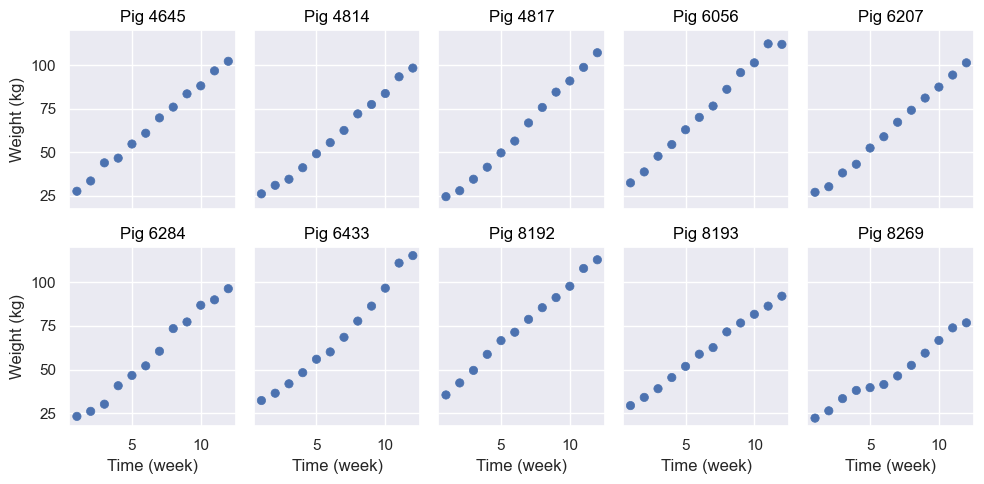

In [12]:
# Time vs Weight for 10 random pigs
rng = np.random.default_rng(SEED)
random_pigs = rng.choice(df["Pig"].unique(), 10, replace=False)
(
    so.Plot(
        df[df["Pig"].isin(random_pigs)],
        x="Time",
        y="Weight",
        group="Pig",
    )
    .add(so.Dot())
    .facet(col="Pig", wrap=5)
    .label(x="Time (week)", y="Weight (kg)", title="Pig {}".format)
    .theme({"figure.figsize": (10, 5)})
).show()

In [13]:
pig, n_pig = df.Pig.factorize()
coords = {"Pig": n_pig}

with pm.Model(coords=coords) as pymc_model:
    # Common-level effects
    α_global = pm.Normal("α_global", mu=60, sigma=20)
    β_global = pm.Normal("β_global", mu=0, sigma=1)

    # Grou-level effects (non-centered parametrization)
    α_specific_offset = pm.Normal("α_specific_offset", mu=0, sigma=1, dims="Pig")
    α_specific_sigma = pm.HalfNormal("α_specific_sigma", sigma=5)
    β_specific_offset = pm.Normal("β_specific_offset", mu=0, sigma=1, dims="Pig")
    β_specific_sigma = pm.HalfNormal("β_specific_sigma", sigma=1)

    α_specific = pm.Deterministic("α_specific", α_specific_offset * α_specific_sigma, dims="Pig")
    β_specific = pm.Deterministic("β_specific", β_specific_offset * β_specific_sigma, dims="Pig")

    # Standard deviation of Y | X (the same as the standard deviation of epsilon_i)
    σ = pm.HalfStudentT("σ", nu=4, sigma=10)

    # Build mu_i
    α = α_global + α_specific[pig]
    β = β_global + β_specific[pig]
    μ = pm.Deterministic("μ", α + β * df["Time"])

    # Observational model
    Y = pm.Normal("Weight", mu=μ, sigma=σ, observed=df["Weight"])

    # Sampling
    pymc_idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
d:\work\025_t_test網頁設計\statistic_platform\backend\.venv\lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α_global, β_global, α_specific_offset, α_specific_sigma, β_specific_offset, β_specific_sigma, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [14]:
az.plot_trace_dist(
    pymc_idata, 
    var_names=["α_global", "β_global", "α_specific", "β_specific", "σ"],
);

AttributeError: module 'arviz.preview' has no attribute 'plot_trace_dist'